# **Bank Fraud Detection** 

This project focuses on detecting fraudulent financial transactions using a large-scale dataset containing over **6.3 million transaction records**. The objective is to build a machine learning model that can accurately identify fraudulent transactions and help financial institutions reduce losses caused by fraud.

#### **Dataset Information:** 
The dataset contains the records of financial transactions for fraud detection. (6.3 Million Records)

**Columns:**

1. step - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 
   (30 days simulation).
2. type - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.
3. amount - amount of the transaction in local currency.
4. nameOrig - customer who started the transaction
5. oldbalanceOrg - initial balance before the transaction
6. newbalanceOrig - new balance after the transaction
7. nameDest - customer who is the recipient of the transaction
8. oldbalanceDest - initial balance recipient before the transaction. Note that there is not 
   information for customers that start with M (Merchants).
9. newbalanceDest - new balance recipient after the transaction. Note that there is not information for 
   customers that start with M (Merchants).
10. isFraud - This is the transactions made by the fraudulent agents inside the simulation. In this 
    specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.
11. isFlaggedFraud - The business model aims to control massive transfers from one account to another 
    and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

**LINK**: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset?resource=download

## Import Libraries & Configuration

In [1]:
# Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer


# Configuration
sns.set_style('darkgrid')
plt.rcParams["figure.figsize"] = (6, 4)

## Load Dataset

In [2]:
# Load the dataset 
df = pd.read_csv('../data/fraud_data.csv')


## Exploratory Data Analysis (EDA)

In [3]:
# Check sample dataset 
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
# Check shape of the dataset 
print(f"Number of Rows: {df.shape[0]}")    
print(f"Number of Columns: {df.shape[1]}")    

Number of Rows: 6362620
Number of Columns: 11


In [5]:
# Check info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [6]:
# Check statistical summary 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [7]:
# Check missing values 
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
# Check duplicate values 
df.duplicated().sum()

np.int64(0)

In [9]:
# Check type, isFraud and isFlaggedFraud total values 

print(df['type'].value_counts())
print("-"*40)
print(df['isFraud'].value_counts())
print("-"*40)
print(df['isFlaggedFraud'].value_counts())

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
----------------------------------------
isFraud
0    6354407
1       8213
Name: count, dtype: int64
----------------------------------------
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64


In [10]:
df.shape

(6362620, 11)

#### Observation: 
- The dataset contains **6362620 Rows** and **11 Columns** .
- There is no any missing and duplicate value in this dataset.
- There is **8213** fraud records and **6354407** normal records.
- The dataset is highly imbalanced.
- Balance-related features (**oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest**) contain many zero values. 
- There is skewness in some columns refers to outliers.

In [11]:
# Check fraud ratio
print(f"Non-Fraud Ratio: {round(df['isFraud'].value_counts(normalize=True)[0]*100,4)}%")
print(f"Fraud Ratio: {round(df['isFraud'].value_counts(normalize=True)[1]*100,4)}%")

Non-Fraud Ratio: 99.8709%
Fraud Ratio: 0.1291%


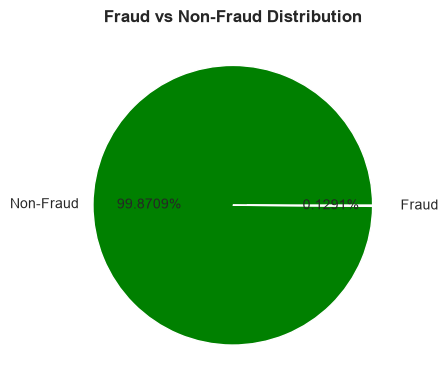

In [12]:
# Fraud vs Non_Fraud Distribution 
fraud_ratio = round(df['isFraud'].value_counts(normalize=True)*100,4)

plt.pie(fraud_ratio,labels=['Non-Fraud','Fraud'],colors=['green', 'red'],autopct='%1.4f%%',explode=(0,0.10))
plt.title('Fraud vs Non-Fraud Distribution', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

type
CASH_OUT    35.17
PAYMENT     33.81
CASH_IN     21.99
TRANSFER     8.38
DEBIT        0.65
Name: proportion, dtype: float64


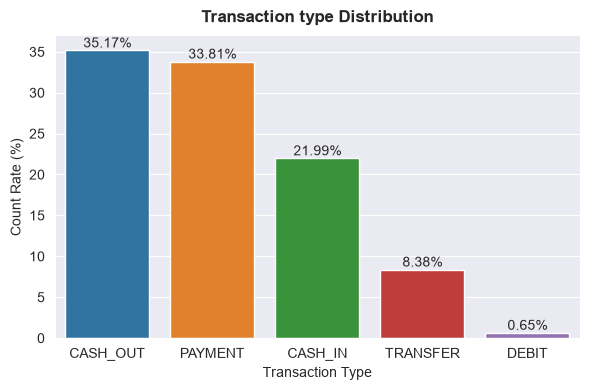

In [13]:
# Check transaction type percentage 
type_percentage = round(df['type'].value_counts(normalize=True)*100,2)
print(type_percentage)

ax = sns.barplot(x=type_percentage.index,y=type_percentage.values,palette='tab10')

plt.title('Transaction type Distribution',fontweight='bold',pad=10)
plt.xlabel('Transaction Type')
plt.ylabel('Count Rate (%)')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')
    
sns.despine() 
plt.tight_layout()
plt.show()

type
TRANSFER    0.77
CASH_OUT    0.18
CASH_IN     0.00
DEBIT       0.00
PAYMENT     0.00
Name: isFraud, dtype: float64


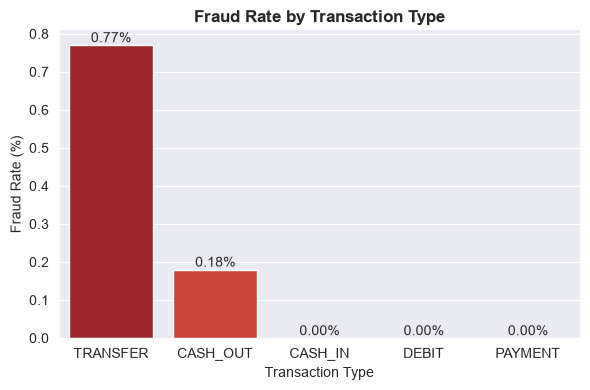

In [14]:
# Check fraud rate by transaction type 
fraud_by_type = round(df.groupby('type')['isFraud'].mean().sort_values(ascending=False)*100,2)
print(fraud_by_type)

ax = sns.barplot( x=fraud_by_type.index,y=fraud_by_type.values,palette='Reds_r')

plt.title('Fraud Rate by Transaction Type', fontweight='bold')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')

# Add labels on bars
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')

sns.despine()
plt.tight_layout()
plt.show()



#### Observation: 
- This dataset is dominated by **CASH_OUT, PAYMENT, and CASH_IN**
- Fraud occurs only in **TRANSFER** and **CASH_OUT** type of transactions. 
- **TRANSFER** has the highest fraud rate - **(77%)**
- **CASH_OUT** has lower fraud rate - **(18%)**
- **PAYMENT**, **CASH_IN**, and **DEBIT** have 0 fraudulent transactions.
- From this insight it looking like Fraudsters first transfer money to another account and then cash it out. This aligns with the dataset description.

In [18]:
# # Define numerical columns 
# numerical_columns = ['step','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

# # Check distribution 
# plt.figure(figsize=(12, 8))

# for i,col in enumerate(numerical_columns,1):
#     plt.subplot(2,3,i)
#     sns.histplot(data=df,x=col,kde=True,bins=20)
#     plt.title(f'{col} Distribution', fontweight='bold', pad=10)
#     plt.xlabel(col)
#     plt.ylabel('Count')

#     sns.despine()

# plt.tight_layout

# plt.show()